## Similarity-based Applicability Domain
- A method to determine the applicability domain of a QSAR model based on similarity as described by [Sahigara et *al*. Journal of Cheminformatics **2013**, 5:27; doi:10.1186/1758-2946-5-27](https://jcheminf.biomedcentral.com/articles/10.1186/1758-2946-5-27) is implemented in class `[utils.sk_qsar.KNeighborAppDom](../utils/sk_qsar.py) and demonstrated in this notebook. 

# Setup Code
## Environment

In [1]:
### use conda environment brd4

import sys

print(sys.executable)

/home/oskar/anaconda3/envs/brd4/bin/python


## Imports

In [ ]:
### Standard imports
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit as rd
import seaborn as sns
import sklearn as sk
from tqdm import tqdm

In [ ]:
### Specific imports

## Jupyter Settings

In [4]:
### Random seed - using the same seed for robustness
SEED = 0
np.random.seed(SEED)

### NumPy arrays - floats
np.set_printoptions(
    precision=2,  # round values
    suppress=True,
)  # avoid scientific notation

### pandas DataFrames
pd.set_option("display.float_format", "{:.2f}".format)  # Round to 2 decimal places

### Initialize tqdm for pandas
tqdm.pandas()

### Suppress RDKit logs
rd.RDLogger.DisableLog("rdApp.*")

### Re-enable logging if needed
# rd.RDLogger.EnableLog('rdApp.*')

## Utils
- `utils/pd_mol.py` contains individual functions for processing rdkit mol objects in pandas DataFrames. 
- `utils/sk_qsar.py` contains individual functions for bulding QSAR models with scikit-learn. 
- The class [`MorganSimilarity`](`../utils/similarity_sali.py`) is used as container for the training data. 

In [ ]:
### Add the utils directory to the path
sys.path.append(os.path.abspath("../utils"))
import sk_qsar
from pd_mol import render_mol
from similarity_sali import MorganSimilarity

# Data

## Training Data

Unpack the training data from the [`RfClfAppDom`](../utils/sk_qsar.py)class object. 

In [6]:
### Load the morgan object
with open("../data/03_rf_ad_class.pkl", "rb") as file:
    rf_app_dom = pickle.load(file)

### Unpacking the random forest model
rf_model = rf_app_dom.rf_model

### Load the transformed training data
X_train = rf_app_dom.X_train

### As DataFrame
X_train_df = pd.DataFrame(X_train)

X_train_df.shape

(2157, 32)

## Test Data

A subset of the combinatorial library will be used as test set in this demonstration. 

original length: 30690
new length: 30690


,Mol
ID,
acid-175_amine-37_yne-662_yne-662,
acid-173_amine-43_yne-2721_yne-2721,
acid-166_amine-28_yne-222_yne-222,

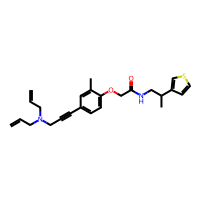
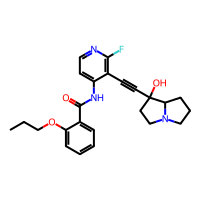
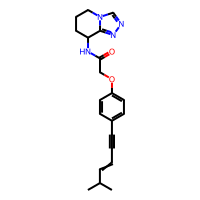

In [7]:
### Load the new data
new_df = pd.read_pickle("../data/02_comb_lib_250_600.pkl")

print(f"original length: {len(new_df)}")
test_df = new_df.sample(2000, random_state=SEED)
print(f"new length: {len(new_df)}")
render_mol(test_df.head(3))

**Morgan Fingerprints**


The features of the training data were generated using method `utils.similarity_sali.MorganSimilarity.get_morgan_fingerprint()`with `radius = 3` and  `nBits = 2048`. Because Morgan fingerprints are deterministic a new instance can be used. 

In [8]:
### Instantiate the class
morgan = MorganSimilarity(test_df, radius=3, nBits=2048, useChirality=True)

### Get the Morgan fingerprints
morgan.get_morgan_fingerprint()

### Format the fingerprints as NumPy array
morgan.format_fp("np_array")

morgan.fp.shape

(2000, 2048)

**PCA**

The number of festures is reduce from **2048** to **32** by the same `PCA` model used to transform the training data.  

In [9]:
### Transform the data using the PCA model used to transform the training data
X_test = rf_app_dom.pca_model.transform(morgan.fp)

### As DataFrame
X_test_df = pd.DataFrame(X_test, index=test_df.index)

X_test_df.shape

(2000, 32)

## Dimensionality Reduction
In order to visualize this method of determining the applicability domain the features will be further reduced in order to allow plotting in 2D. 

*Note:* The chosen parameters for the t-SNE model have a strong affect on the distances between train and test data. Thus, also affect the applicability domain. 

<Figure size 1000x800 with 0 Axes>

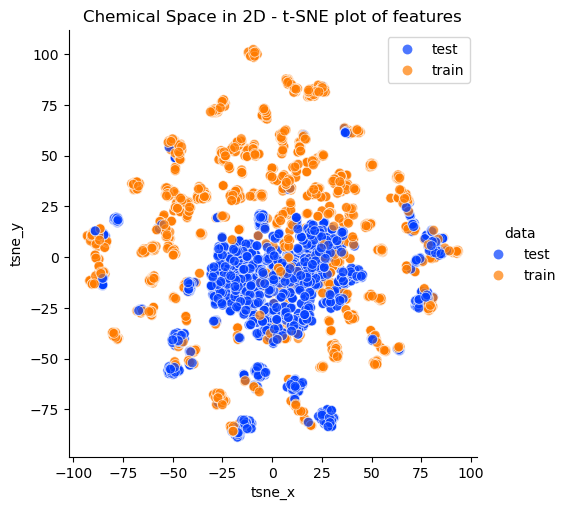

In [10]:
### Combine the training and test data
X_df = pd.concat([X_train_df, X_test_df], axis=0)

### Shuffle the data
X_df = X_df.sample(random_state=SEED, frac=1)

### Perform t-SNE
tsne = sk.manifold.TSNE(
    n_components=2, random_state=SEED, perplexity=20, learning_rate=200
)
X_tsne = tsne.fit_transform(X_df.values)

### Create a DataFrame for the t-SNE results
tsne_df = pd.DataFrame(X_tsne, columns=["tsne_x", "tsne_y"], index=X_df.index)

### Specify in 'data' whether it is train or test
tsne_df["data"] = "train"
tsne_df.loc[X_test_df.index, "data"] = "test"

### Plot the t-SNE results
plt.figure(figsize=(10, 8))
sns.relplot(
    x="tsne_x",
    y="tsne_y",
    data=tsne_df,
    kind="scatter",
    hue="data",
    palette="bright",
    alpha=0.7,
    s=50,
)
plt.title("Chemical Space in 2D - t-SNE plot of features")
plt.legend()
plt.show()

Plotting the same data side-by-side

<Figure size 1000x800 with 0 Axes>

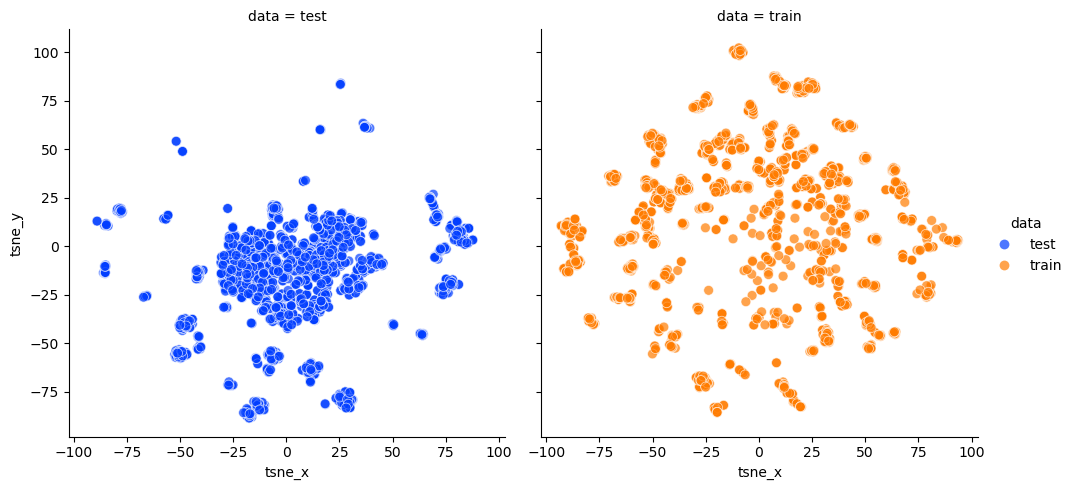

In [11]:
### Plot the t-SNE results
plt.figure(figsize=(10, 8))
sns.relplot(
    x="tsne_x",
    y="tsne_y",
    data=tsne_df,
    kind="scatter",
    hue="data",
    col="data",
    palette="bright",
    alpha=0.7,
    s=50,
)
plt.show()

In [12]:
### Split train and test data in two separate DataFrames
train_tsne_df = tsne_df[tsne_df["data"] == "train"].drop(columns="data")
test_tsne_df = tsne_df[tsne_df["data"] == "test"].drop(columns="data")

train_tsne_df.shape, test_tsne_df.shape

((2157, 2), (2000, 2))

# Applicability Domain in 2D
This section demonstrates how to use the [`KNeighborAppDom`](../utils/sk_qsar.py) class. 

**Select `k`**

The only tunable parameter for this method is `k`. It determines the number of neighbors to include for calculating the radius around every training point. Every test compound within the radius of a single training compound is considered to be within the applicability domain of the model. Thus
- small `k` result in strict AD boundaries
- large `k` result in soft AD boundaries

The function `KNeighborAppDom.explore_k()` can be used to choose a value for `k`. It only considers the training data and a list of values for `k`. The function plots `k` against 
- The number of train compounds with an `AD radius = 0` (blue). These compounds will not be affective when determining the AD for a similar test compound. 
- The number of train compounds out of AD, if their AD boundary is not considered (orange). *Note:* in this calculation the respective boundary is removed, not its effect on the global reference value. Therefor the name "quasi leave-one out".  

100%|██████████| 24/24 [00:00<00:00, 36.69it/s]


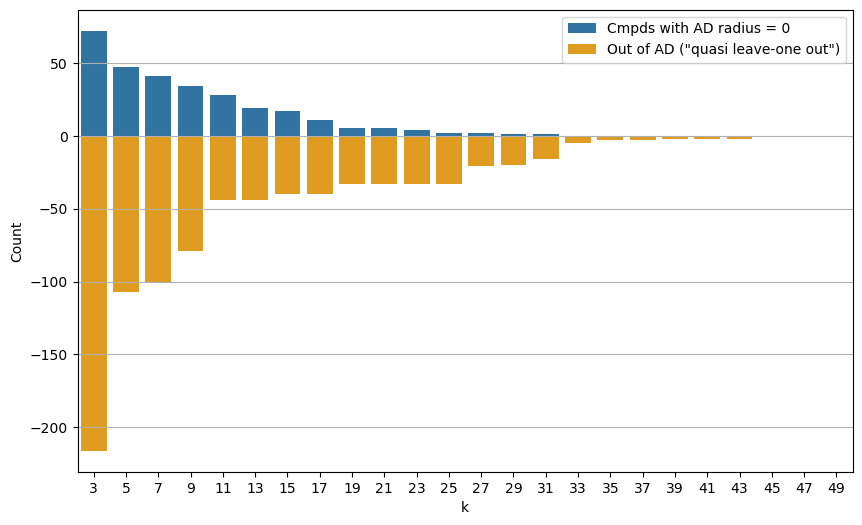

In [13]:
### Instantiate the AD model
AD = sk_qsar.KNeighborAppDom()

### Explore different k values
ks = range(3, 50, 2)
AD.explore_k(train_tsne_df, ks)

**Visualization**

As we are using only two features in this demonstration, the boundaries can be visualized. The plot below demonstrates the boundaries for different values of `k`. 

100%|██████████| 4/4 [00:32<00:00,  8.07s/it]


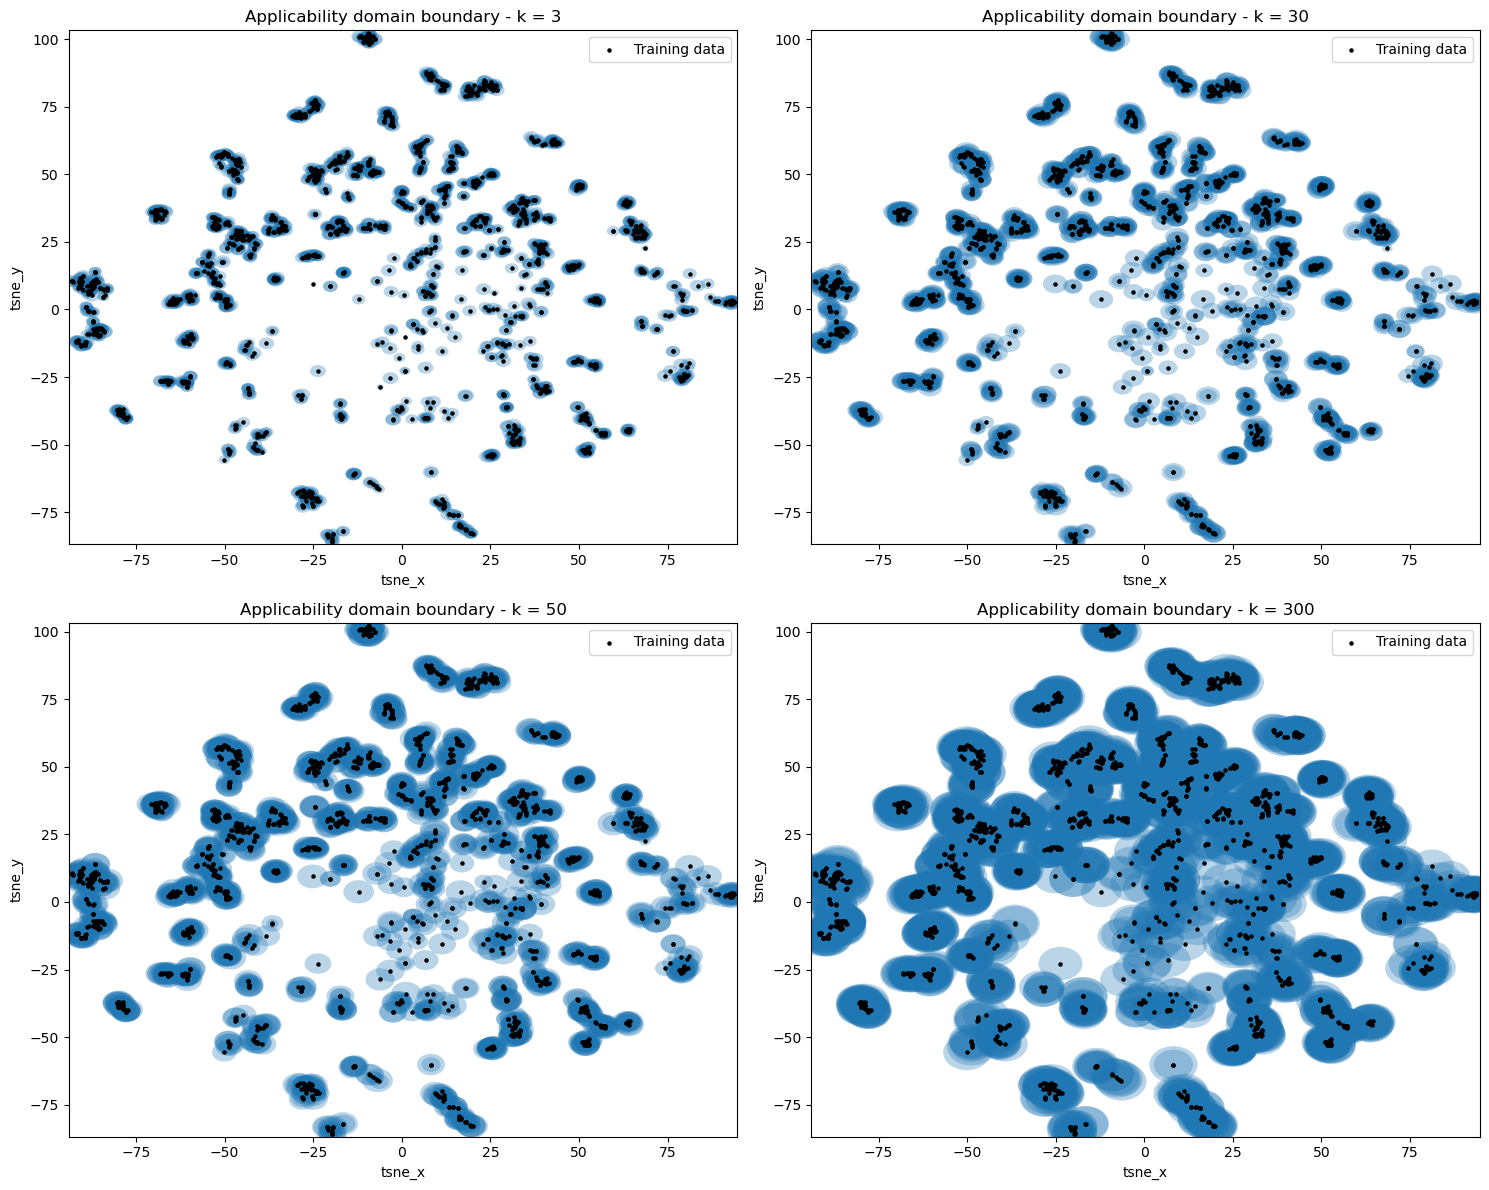

In [14]:
### Define k values to visualize
k_values = [3, 30, 50, 300]

### Define training data points
points = train_tsne_df.values

### Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

### Flatten axes for easier indexing
axes = axes.flatten()

### Loop over the k values
for idx, k in enumerate(tqdm(k_values)):
    ### Instantiate the AD model
    AD = sk_qsar.KNeighborAppDom()

    ### Train the AD model with selected k
    AD.fit(X_train_df, k=k)

    ### Plot on the corresponding subplot
    ax = axes[idx]

    ### Plot AD boundary
    for i, radius in enumerate(AD.AD_thresholds):
        circle = plt.Circle((points[i, 0], points[i, 1]), radius, fill=True, alpha=0.3)
        ax.add_patch(circle)

    ### Plot the training data
    ax.scatter(points[:, 0], points[:, 1], c="black", s=5, label="Training data")

    ax.set_title(f"Applicability domain boundary - k = {k}")
    ax.set_xlabel("tsne_x")
    ax.set_ylabel("tsne_y")
    ax.legend()
    ax.set_xlim(points[:, 0].min() - 1, points[:, 0].max() + 1)
    ax.set_ylim(points[:, 1].min() - 1, points[:, 1].max() + 1)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

**Predict Test Compounds**
Once `k` is selected `KNeighborAppDom.fit()` is used to train the model and `KNeighborAppDom.predict()` is used to classify test compounds. Here `k = 3` is chosen to achieve very strict AD boundaries for demonstration purposes. `KNeighborAppDom.predict()` returns a DataFrame with:
- ID: index of the test compound
- AD_status: boolean - AD classification
- AD_density: integer - number of training cmpds within the respective AD radius
- train_neibs_idx - list of train cmpd indexes within the respective AD radius if return_neighbors=True 

In [15]:
### Instantiate the AD model
AD = sk_qsar.KNeighborAppDom()

### Train the AD model with selected k
AD.fit(X_train_df, k=3)

In [16]:
### Query test set
AD.predict(X_test_df, return_neighbors=True)

Shape of distance matrix: (2000, 2157) (test x training cmpds)
1267 (63%) compounds are within AD


,AD_status,AD_density,train_neigbs_idx
ID,,,
acid-175_amine-37_yne-662_yne-662,True,5,"[1680, 304, 1052, 375, 586]"
acid-173_amine-43_yne-2721_yne-2721,True,1,[136]
acid-166_amine-28_yne-222_yne-222,False,0,[]
acid-187_amine-11_yne-3823_yne-3823,True,3,"[211, 578, 1168]"
acid-75_amine-22,True,1,[1222]
...,...,...,...
acid-39_amine-9_yne-222_yne-222,True,3,"[734, 310, 1414]"
acid-15_amine-34_yne-1143_yne-1143,False,0,[]
acid-163_amine-36_yne-4098_yne-4098,True,2,"[1286, 764]"


# Hyperparameter tuning

100%|██████████| 24/24 [00:00<00:00, 32.63it/s]


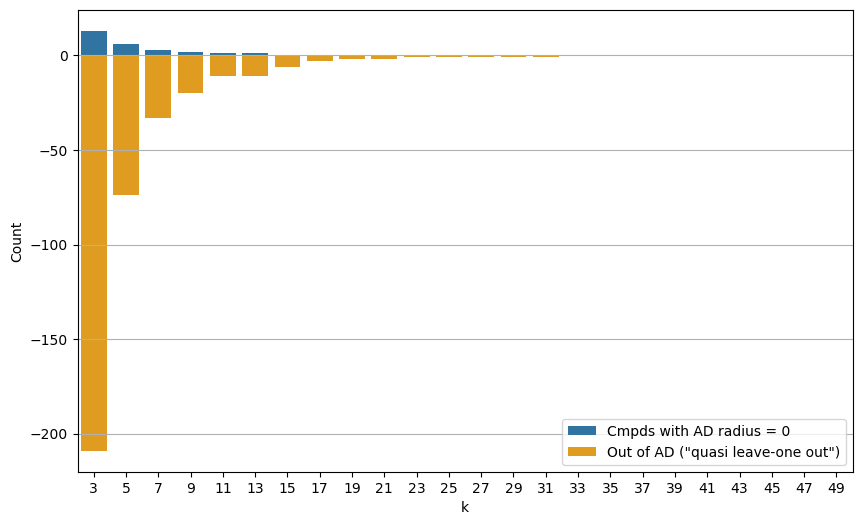

In [17]:
### Instantiate the AD model
AD = sk_qsar.KNeighborAppDom()

### Explore different k values
ks = range(3, 50, 2)
AD.explore_k(X_train_df, ks)

### Choose `k`
- `k = 9` 
    - 'elbow'
    - for a very restrictive AD boundaries
    - not recommended (too restrictive to ensure novelty)
- `k = 15`
    - to ensure all training data are utilized 
    - recommended
- `k = 33`
    - to ensure all training data are within AD
    - not recommended (too tolerant to ensure predictability)


In [18]:
### Fit the AD model
AD.fit(X_train_df, k=15)

## Export 
### KNN model
All required data is associated with the object in this file

In [ ]:
with open("../data/03_knn_ad_model.pkl", "wb") as file:
    pickle.dump(AD, file)